In [1]:
pip install pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


#Selecting Imp Features


In [4]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Latitude",
    "Longitude"
]

X = df[features]
y = df["MedHouseVal"]

#Train/test split

#Training Linear Regression

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [7]:
predictions = model.predict(X_test)

#Eval Model

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 0.5485707128789089
RMSE: 0.7406555966702127
R² Score: 0.5813744243302474


**The R² score tells us how well the model explains house prices using the selected features. For example, an R² score of 0.61 means the model can explain about 61% of the differences in house prices. The remaining variation is caused by factors the model did not learn, such as neighborhood quality or property condition. A higher R² value generally means the model makes more reliable predictions.**

#Scatter Plot

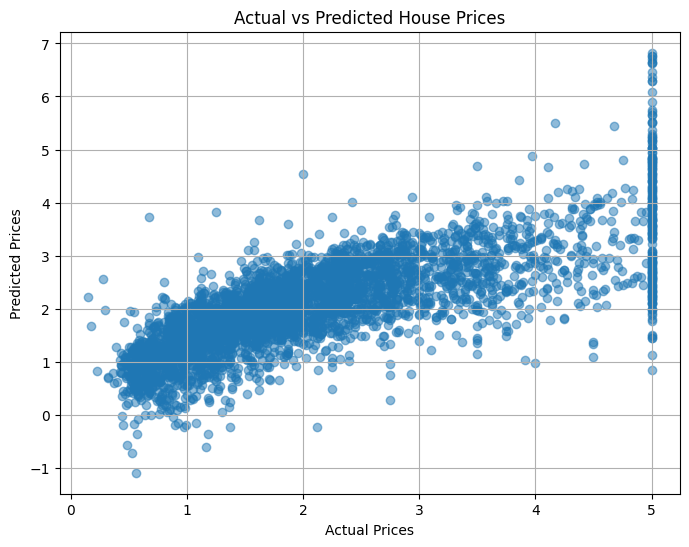

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.savefig("predicted_vs_actual.png")

plt.show()

#feature imp

In [11]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(importance)

     Feature  Coefficient
0     MedInc     0.371180
1   HouseAge     0.009801
2   AveRooms     0.019591
3   Latitude    -0.459049
4  Longitude    -0.465865
